In [1]:
import sys
print(sys.version)
print(sys.executable)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Scripts\python.exe


In [2]:
from tensorflow.keras.preprocessing import image_dataset_from_directory


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
import os

data_dir = "dataset"
DATASET_PATH = "dataset"

counts = []

for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)

    if os.path.isdir(cls_path):
        counts.append([cls, len(os.listdir(cls_path))])

df_counts = pd.DataFrame(counts,
                         columns=["Class", "Count"])

print(df_counts)

           Class  Count
0     algal leaf    149
1   brown blight    150
2        healthy    146
3  red leaf spot    143
4     white spot    136


## Exploratory Data Analysis (EDA)

Visual Inspection

In [27]:
#Check image sizes

dataset_path = "dataset"

sizes = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            try:
                img = Image.open(os.path.join(folder_path, file))
                sizes.append(img.size)
            except:
                pass

df = pd.DataFrame(sizes, columns=["width", "height"])

print(df.describe())

       width height
count      0      0
unique     0      0
top      NaN    NaN
freq     NaN    NaN


In [6]:
# Detect Blurry Images

import cv2

dataset_path = "dataset"

blurry_count = 0
total_images = 0

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            path = os.path.join(folder_path, file)
            img = cv2.imread(path)

            if img is None:
                continue
            total_images += 1
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
            if blur_score < 100:
                blurry_count += 1

print(f"Total images: {total_images}")
print(f"Blurry images: {blurry_count}")
print(f"Percentage blurry: {100 * blurry_count / total_images:.2f}%")

Total images: 724
Blurry images: 608
Percentage blurry: 83.98%


In [ ]:
# check brigthness

brightness = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            img = cv2.imread(
                os.path.join(folder_path, file),
                cv2.IMREAD_GRAYSCALE
            )
            if img is not None:
                brightness.append(np.mean(img))

print("Average brightness:", np.mean(brightness))

Average brightness: 183.41155314458013


In [135]:
# bad images

total_images = 0
corrupted_images = 0

for folder in os.listdir("dataset"):
    folder_path = os.path.join("dataset", folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            total_images += 1
            try:
                img = Image.open(
                    os.path.join(folder_path, file)
                )
                img.verify()
            except Exception:
                corrupted_images += 1
                print("Corrupted:", file)

print(f"Total images: {total_images}")
print(f"Corrupted images: {corrupted_images}")

Total images: 724
Corrupted images: 0


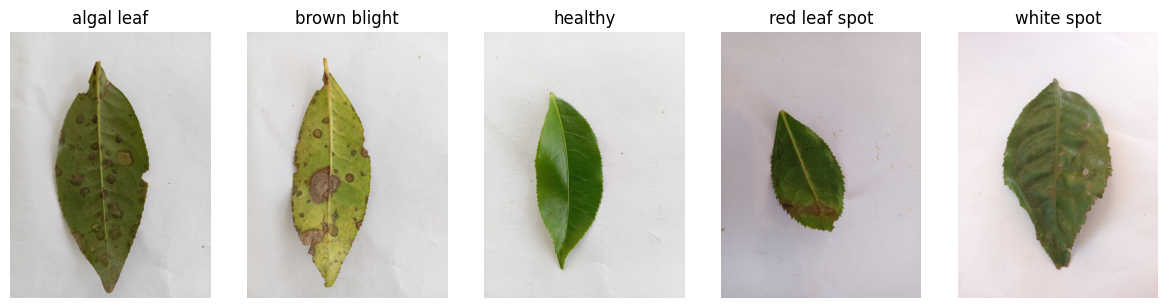

In [123]:
dataset_path = "dataset"

plt.figure(figsize=(12,6))

for i, folder in enumerate(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        image_file = os.listdir(folder_path)[1]

        img = Image.open(
            os.path.join(folder_path, image_file)
        )

        plt.subplot(2, len(os.listdir(dataset_path)), i+1)
        plt.imshow(img)
        plt.title(folder)
        plt.axis('off')

plt.tight_layout()
plt.show()

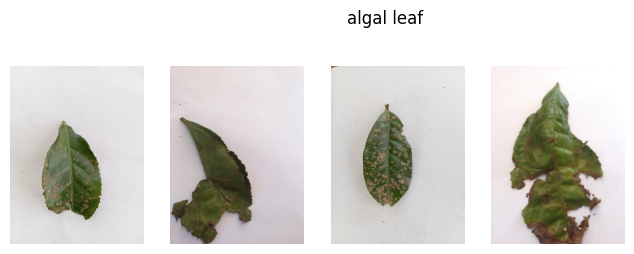

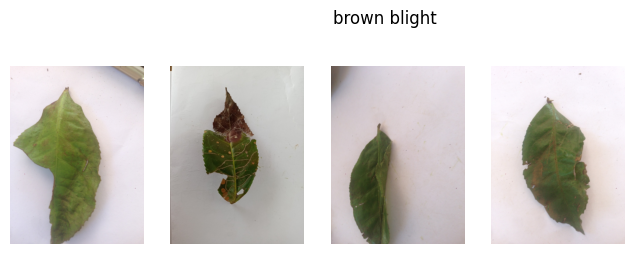

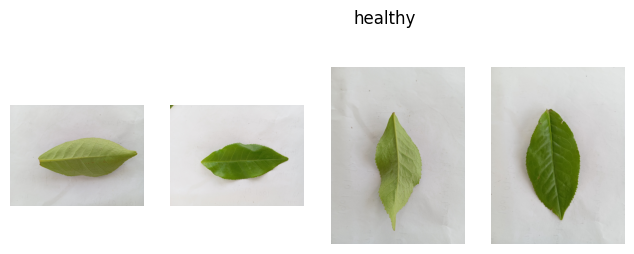

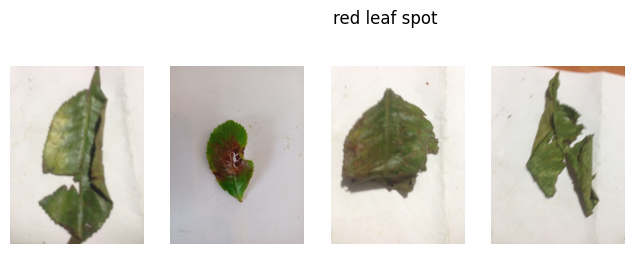

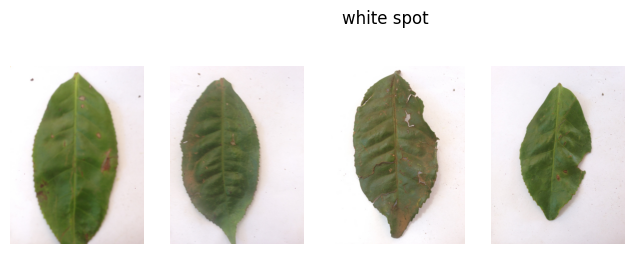

In [106]:
from PIL import Image
import random
dataset_path = "dataset"

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        plt.figure(figsize=(10,3))

        files = random.sample(
            os.listdir(folder_path),
            min(4, len(os.listdir(folder_path)))
        )

        for i, file in enumerate(files):

            img = Image.open(
                os.path.join(folder_path, file)
            )

            plt.subplot(1,5,i+1)
            plt.imshow(img)
            plt.axis('off')

        plt.suptitle(folder)
        plt.show()

In [8]:
import os

folder_all = "dataset/healthy"
image_files = os.listdir(folder_all)

print(image_files[:5])

['healthy_00011.jpg', 'healthy_00012.jpg', 'healthy_00013.jpg', 'healthy_00014.jpg', 'healthy_00015.jpg']


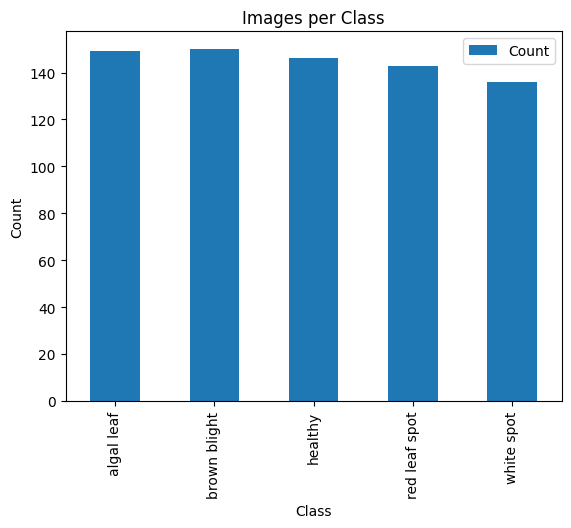

In [108]:
df_counts.plot(
    x='Class',
    y='Count',
    kind='bar'
)

plt.title('Images per Class')
plt.ylabel('Count')
plt.show()

Create Data Generators

Process Images

In [9]:
IMG_SIZE = 224  #target image resolution.
BATCH_SIZE = 25
#dataset_path = "dataset/"    #images path



In [10]:
# Load all images into an array
# Every image gets normalized as it's loaded.
# Data augmentation - new variations of your limited dataset: with this model would overfitt (memorize all images)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,       #Splits dataset into training and validation
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

Load Train Data

In [11]:
train_data = datagen.flow_from_directory(
    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 581 images belonging to 5 classes.


Load Validation Data

In [12]:
val_data = datagen.flow_from_directory(
    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False           # turn off shuffle
)

Found 143 images belonging to 5 classes.


Check Class Mapping

In [113]:
print(train_data.class_indices)

{'algal leaf': 0, 'brown blight': 1, 'healthy': 2, 'red leaf spot': 3, 'white spot': 4}


In [114]:
#save it
class_names = list(train_data.class_indices.keys())
print(class_names)

['algal leaf', 'brown blight', 'healthy', 'red leaf spot', 'white spot']


Create callbacks

In [13]:
# Early stoppage
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',         # what to watch
    patience=5,
    restore_best_weights=True   # go back to best model
)

In [14]:
# Save best model automatically
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",

    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

MODEL 1: CNN

In [118]:
# Build CNN
cnn_model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),   # “decision-making brain layer”
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax') # Produces probabilities for 5 classes - Sofmax ensures all outputs sum to 1
])

c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Build CNN new
from tensorflow.keras import models, layers, regularizers

cnn_model = models.Sequential([
    # Layer 1: Keep initial feature extraction gentle
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # Layer 2: Extract mid-level textures/shapes
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # Layer 3: Extract deeper, complex disease spot structures
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # Layer 4: NEW - Added an extra convolutional block for fine-grained color/pattern extraction
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # Replace Flatten with GlobalAveragePooling2D to prevent overfitting & reduce parameters
    layers.GlobalAveragePooling2D(),
    
    # The Decision-Making Layer (Enhanced with L2 Regularization to stop the "white spot" bias)
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    
    # Final Output Layer for your 5 classes
    layers.Dense(5, activation='softmax')
])

c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile

# “decision-making brain layer”
# configures how your neural network will learn. It does NOT train the model yet—it just sets the rules for training
from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),               # how to learn - learning rate.
    #optimizer='adam',  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# compile

# “decision-making brain layer”
# configures how your neural network will learn. It does NOT train the model yet—it just sets the rules for training



In [123]:
#train

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 807ms/step - accuracy: 0.5852 - loss: 0.9495 - val_accuracy: 0.6713 - val_loss: 0.8615
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 806ms/step - accuracy: 0.6041 - loss: 0.9298 - val_accuracy: 0.6434 - val_loss: 0.8344
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 754ms/step - accuracy: 0.6093 - loss: 0.9108 - val_accuracy: 0.6643 - val_loss: 0.8144
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 724ms/step - accuracy: 0.6231 - loss: 0.8930 - val_accuracy: 0.5874 - val_loss: 0.9061
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 734ms/step - accuracy: 0.6592 - loss: 0.8463 - val_accuracy: 0.7133 - val_loss: 0.7994
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 741ms/step - accuracy: 0.6695 - loss: 0.7695 - val_accuracy: 0.7063 - val_loss: 0.7579
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 757ms/step - accuracy: 0.7177 - loss: 0.7278 - val_accuracy: 0.7762 - val_loss: 0.6271
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 766ms/step - accuracy: 0.7281 - loss: 0.6840 - val_accu

In [124]:
# Evaluate

cnn_loss, cnn_acc = cnn_model.evaluate(val_data)
print(cnn_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.8042 - loss: 0.4671
0.8041958212852478


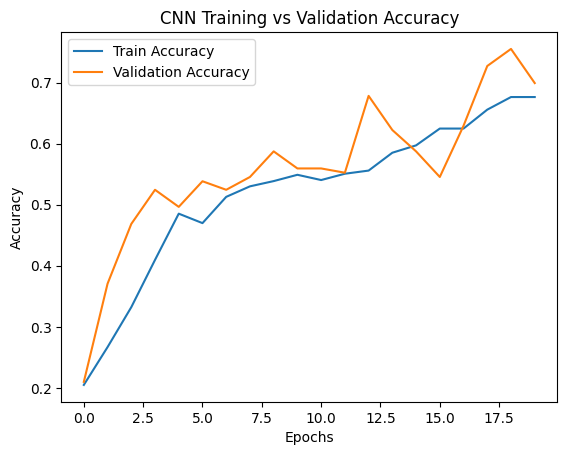

In [21]:
plt.figure()

plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

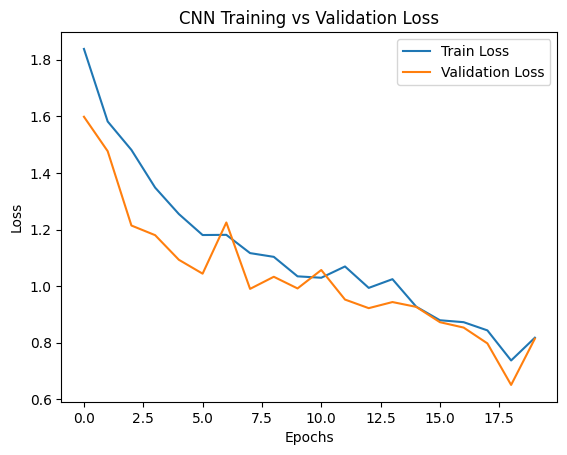

In [22]:
plt.figure()

plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title('CNN Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [23]:
print(max(cnn_history.history['accuracy']))
print(max(cnn_history.history['val_accuracy']))

0.6764199733734131
0.7552447319030762


MODEL 2: MobileNetV2

In [15]:
from tensorflow.keras.applications import MobileNetV2

#Load Base Model
mobile_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [16]:
#freeze it

mobile_base.trainable = False

In [17]:
# Build MV2 Model

mobile_model = models.Sequential([

    mobile_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
])


In [18]:
# Compile

mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [19]:
# Train

mobile_history = mobile_model.fit(
    train_data,

    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)


Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 938ms/step - accuracy: 0.2134 - loss: 1.9085 - val_accuracy: 0.3077 - val_loss: 1.5470
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 872ms/step - accuracy: 0.3098 - loss: 1.5831 - val_accuracy: 0.4476 - val_loss: 1.4220
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 897ms/step - accuracy: 0.4596 - loss: 1.3249 - val_accuracy: 0.5315 - val_loss: 1.2633
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 707ms/step - accuracy: 0.5353 - loss: 1.1928 - val_accuracy: 0.5175 - val_loss: 1.1696
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 682ms/step - accuracy: 0.5886 - loss: 1.0633 - val_accuracy: 0.5944 - val_loss: 1.1189
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 726ms/step - accuracy: 0.6317 - loss: 0.9792 - val_accuracy: 0.6084 - val_loss: 1.0910
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 710ms/step - accuracy: 0.6781 - loss: 0.8878 - val_accuracy: 0.5874 - val_loss: 1.0667
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 685ms/step - accuracy: 0.6609 - loss: 0.8731 - val_accu

In [29]:
# Fine Tune MV2

#unfreeze
mobile_base.trainable = True


#recompile
mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
mobile_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.6592 - loss: 0.8598 - val_accuracy: 0.3916 - val_loss: 2.6956
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7952 - loss: 0.4926 - val_accuracy: 0.1958 - val_loss: 35.2290
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8812 - loss: 0.3248 - val_accuracy: 0.1958 - val_loss: 28.9691
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8812 - loss: 0.3593 - val_accuracy: 0.2867 - val_loss: 21.5947
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8795 - loss: 0.3372 - val_accuracy: 0.3077 - val_loss: 13.5351


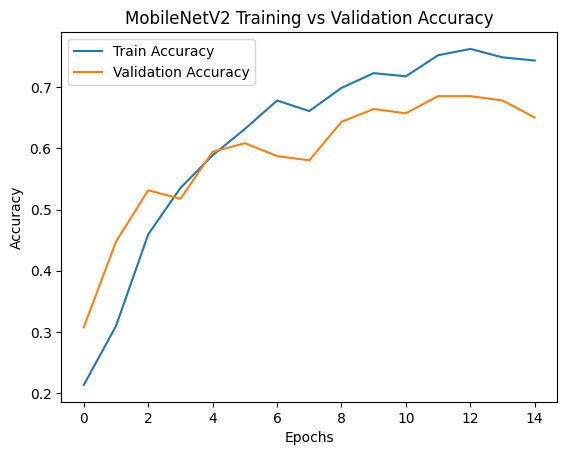

In [20]:
plt.figure()

plt.plot(mobile_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobile_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('MobileNetV2 Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

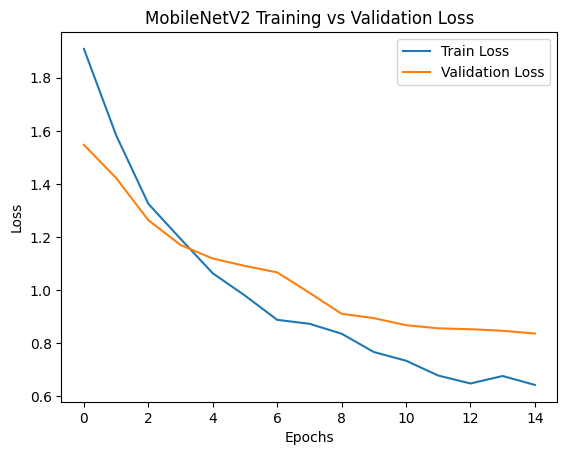

In [21]:
plt.figure()

plt.plot(mobile_history.history['loss'], label='Train Loss')
plt.plot(mobile_history.history['val_loss'], label='Validation Loss')

plt.title('MobileNetV2 Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [22]:
print(max(mobile_history.history['accuracy']))
print(max(mobile_history.history['val_accuracy']))

0.7624784708023071
0.6853147149085999


MODEL 3: ResNet50

In [34]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

#Freeze base model
resnet_base.trainable = False

In [35]:
#build
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
])


In [36]:
#compile
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [37]:
# Train
resnet_history = resnet_model.fit(train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.2186 - loss: 1.6932 - val_accuracy: 0.2098 - val_loss: 1.6157
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1807 - loss: 1.6544 - val_accuracy: 0.1678 - val_loss: 1.6089
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.1979 - loss: 1.6638 - val_accuracy: 0.2028 - val_loss: 1.6142
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.2186 - loss: 1.6465 - val_accuracy: 0.1608 - val_loss: 1.6086
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.2444 - loss: 1.6235 - val_accuracy: 0.2308 - val_loss: 1.6110


In [38]:
#FINE TUNE

#unfreeze
resnet_base.trainable = True

#Recompile
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [39]:
#Train

resnet_history = resnet_model.fit(train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 175s 6s/step - accuracy: 0.2857 - loss: 1.6287 - val_accuracy: 0.1958 - val_loss: 1.6257
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - accuracy: 0.5336 - loss: 1.1909 - val_accuracy: 0.2308 - val_loss: 1.6376
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 133s 6s/step - accuracy: 0.6248 - loss: 0.9850 - val_accuracy: 0.2448 - val_loss: 1.6839
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 131s 5s/step - accuracy: 0.7040 - loss: 0.8217 - val_accuracy: 0.2098 - val_loss: 1.8527
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.7298 - loss: 0.7442 - val_accuracy: 0.2028 - val_loss: 1.9360


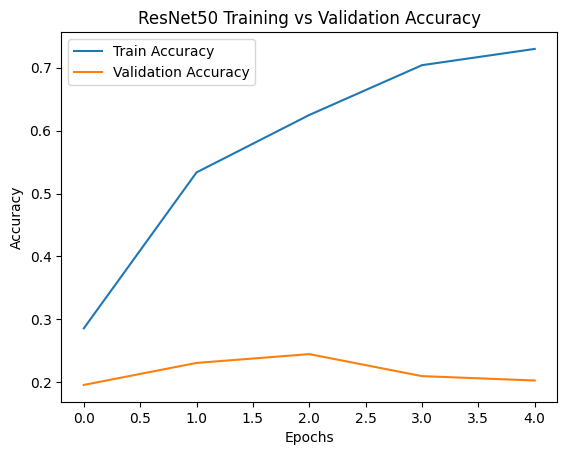

In [40]:
plt.figure()

plt.plot(resnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('ResNet50 Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

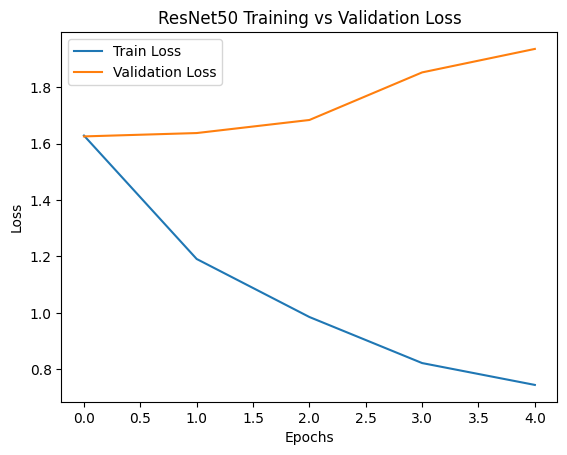

In [41]:
plt.figure()

plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Validation Loss')

plt.title('ResNet50 Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [42]:
print(max(resnet_history.history['accuracy']))
print(max(resnet_history.history['val_accuracy']))

0.7297762632369995
0.24475523829460144


MODEL 4: VGG16

In [23]:
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [44]:
#Freeze Base

vgg_base.trainable = False

In [24]:
#Build

vgg_model = models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

In [25]:
# compile

vgg_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
# Train

vgg_history = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 375s 16s/step - accuracy: 0.2238 - loss: 1.6442 - val_accuracy: 0.2098 - val_loss: 1.6098
Epoch 2/15
18/24 ━━━━━━━━━━━━━━━━━━━━ 2:02 20s/step - accuracy: 0.2075 - loss: 1.6136

KeyboardInterrupt: 

In [48]:
# FINE TUNE

#unfreeze
vgg_base.trainable = True

#recompile
vgg_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
vgg_history = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 334s 14s/step - accuracy: 0.3046 - loss: 1.6190 - val_accuracy: 0.3287 - val_loss: 1.5382
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 339s 14s/step - accuracy: 0.3373 - loss: 1.5138 - val_accuracy: 0.4895 - val_loss: 1.4235
Epoch 3/10
12/24 ━━━━━━━━━━━━━━━━━━━━ 2:39 13s/step - accuracy: 0.4458 - loss: 1.3526

KeyboardInterrupt: 

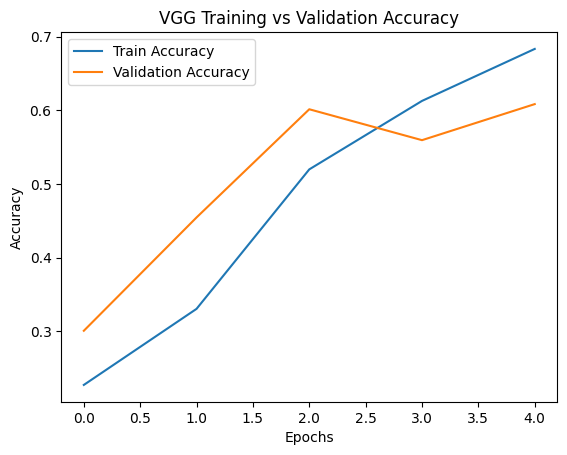

In [204]:
plt.figure()

plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('VGG Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

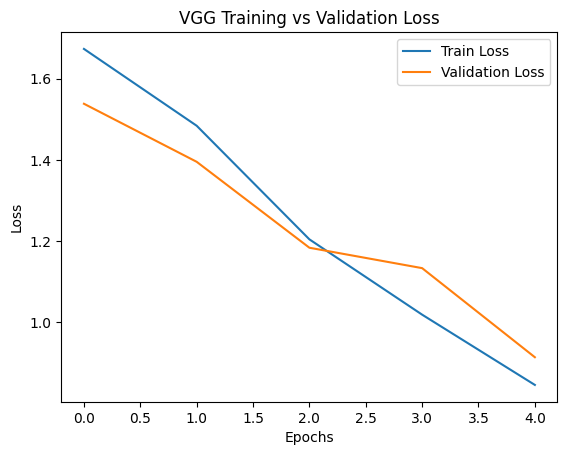

In [203]:
plt.figure()

plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Validation Loss')

plt.title('VGG Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [191]:
print(max(vgg_history.history['accuracy']))
print(max(vgg_history.history['val_accuracy']))

0.6833046674728394
0.6083915829658508


MODEL 5: EfficientNetB0

In [50]:
from tensorflow.keras.applications import EfficientNetB0

#LOAD
efficient_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

In [51]:
#freeze

efficient_base.trainable = False

In [52]:
#Build Model

efficient_model = models.Sequential([

    efficient_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
])

In [53]:
# Compile

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
#Train

efficient_history = efficient_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.1992 - loss: 1.6451
Epoch 1: val_accuracy improved from None to 0.20280, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 882ms/step - accuracy: 0.1893 - loss: 1.6361 - val_accuracy: 0.2028 - val_loss: 1.6197
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.1661 - loss: 1.6357
Epoch 2: val_accuracy improved from 0.20280 to 0.20979, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.1704 - loss: 1.6310 - val_accuracy: 0.2098 - val_loss: 1.6116
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.1862 - loss: 1.6304
Epoch 3: val_accuracy did not improve from 0.20979
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 989ms/step - accuracy: 0.1824 - loss: 1.6258 - val_accuracy: 0.2028 - val_loss: 1.6157
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accurac

In [55]:
#Fine tune B0

efficient_base.trainable = True

efficient_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
efficient_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.2220 - loss: 1.6580 - val_accuracy: 0.1958 - val_loss: 1.6167
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.2255 - loss: 1.6092 - val_accuracy: 0.1888 - val_loss: 1.6139
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.2530 - loss: 1.5559 - val_accuracy: 0.1888 - val_loss: 1.6137
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.3184 - loss: 1.4906 - val_accuracy: 0.2028 - val_loss: 1.6093
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.3838 - loss: 1.4513 - val_accuracy: 0.2028 - val_loss: 1.6129


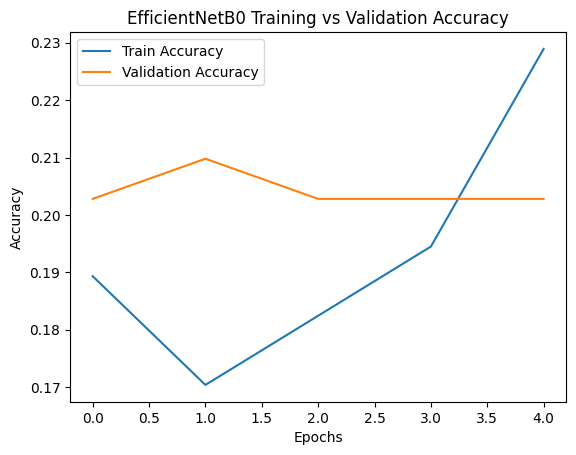

In [57]:
plt.figure()

plt.plot(efficient_history.history['accuracy'], label='Train Accuracy')
plt.plot(efficient_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('EfficientNetB0 Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

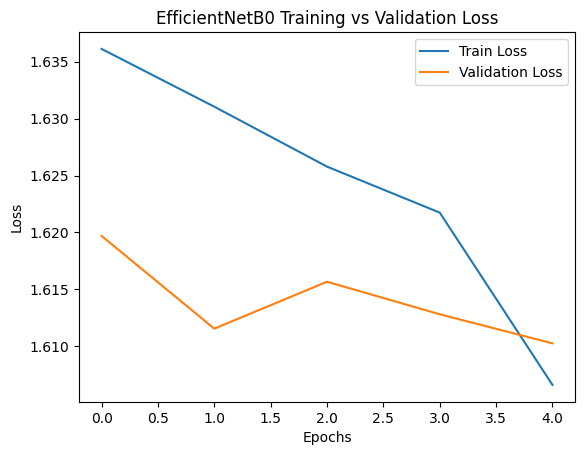

In [58]:
plt.figure()

plt.plot(efficient_history.history['loss'], label='Train Loss')
plt.plot(efficient_history.history['val_loss'], label='Validation Loss')

plt.title('EfficientNetB0 Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [59]:
print(max(efficient_history.history['accuracy']))
print(max(efficient_history.history['val_accuracy']))

0.22891566157341003
0.2097902148962021


**EfficientNetB0**
Model is not learning at all.

### Classification Report

In [60]:
val_data.reset()

pred = efficient_model.predict(val_data)
y_pred = np.argmax(pred, axis=1)

print(
    classification_report(
        val_data.classes,
        y_pred,
        target_names=class_names
    )
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 54s 10s/step
               precision    recall  f1-score   support

   algal leaf       0.00      0.00      0.00        29
 brown blight       0.00      0.00      0.00        30
      healthy       0.00      0.00      0.00        29
red leaf spot       0.20      1.00      0.33        28
   white spot       0.00      0.00      0.00        27

     accuracy                           0.20       143
    macro avg       0.04      0.20      0.07       143
 weighted avg       0.04      0.20      0.06       143



c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [62]:
val_data.reset()

pred = mobile_model.predict(val_data)
y_pred = np.argmax(pred, axis=1)

print(
    classification_report(
        val_data.classes,
        y_pred,
        target_names=class_names
    )
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 566ms/step
               precision    recall  f1-score   support

   algal leaf       0.28      0.62      0.39        29
 brown blight       0.00      0.00      0.00        30
      healthy       0.35      0.72      0.47        29
red leaf spot       0.63      0.43      0.51        28
   white spot       0.00      0.00      0.00        27

     accuracy                           0.36       143
    macro avg       0.25      0.35      0.27       143
 weighted avg       0.25      0.36      0.27       143



c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [127]:
val_data.reset()

pred = cnn_model.predict(val_data)
y_pred = np.argmax(pred, axis=1)

print(
    classification_report(
        val_data.classes,
        y_pred,
        target_names=class_names
    )
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step
               precision    recall  f1-score   support

   algal leaf       0.88      0.79      0.84        29
 brown blight       0.72      0.70      0.71        30
      healthy       1.00      1.00      1.00        29
red leaf spot       0.96      0.93      0.95        28
   white spot       0.66      0.78      0.71        27

     accuracy                           0.84       143
    macro avg       0.85      0.84      0.84       143
 weighted avg       0.85      0.84      0.84       143



Compare results

In [128]:
val_data.reset()

from sklearn.metrics import classification_report, accuracy_score

def evaluate_model(model, data, model_name, class_names):
    
    data.reset()

    # Predict probabilities
    y_pred_prob = model.predict(data)

    # Convert to class labels
    y_pred = np.argmax(y_pred_prob, axis=1)

    # True labels
    y_true = data.classes

    # Accuracy
    acc = accuracy_score(y_true, y_pred)

    print(f"\n================ {model_name} ================")
    print(f"Accuracy: {acc:.4f}\n")

    # Full classification report
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    return acc

In [129]:
cnn_acc = evaluate_model(
    cnn_model,
    val_data,
    "Custom CNN",
    class_names
)

mobile_acc = evaluate_model(
    mobile_model,
    val_data,
    "MobileNetV2",
    class_names
)

resnet_acc = evaluate_model(
    resnet_model,
    val_data,
    "ResNet50",
    class_names
)

vgg_acc = evaluate_model(
    vgg_model,
    val_data,
    "VGG16",
    class_names
)

efficient_acc = evaluate_model(
    efficient_model,
    val_data,
    "EfficientNetB0",
    class_names
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 264ms/step

================ Custom CNN ================
Accuracy: 0.8042

               precision    recall  f1-score   support

   algal leaf       0.92      0.79      0.85        29
 brown blight       0.67      0.53      0.59        30
      healthy       0.97      1.00      0.98        29
red leaf spot       0.97      1.00      0.98        28
   white spot       0.54      0.70      0.61        27

     accuracy                           0.80       143
    macro avg       0.81      0.81      0.80       143
 weighted avg       0.81      0.80      0.80       143

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 462ms/step

================ MobileNetV2 ================
Accuracy: 0.3497

               precision    recall  f1-score   support

   algal leaf       0.29      0.66      0.40        29
 brown blight       0.00      0.00      0.00        30
      healthy       0.30      0.62      0.40        29
red leaf spot       0.72      0.46      0.57        28
   white spot      

c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

================ ResNet50 ================
Accuracy: 0.2937

               precision    recall  f1-score   support

   algal leaf       0.37      0.34      0.36        29
 brown blight       0.00      0.00      0.00        30
      healthy       0.27      0.72      0.39        29
red leaf spot       0.29      0.39      0.33        28
   white spot       0.00      0.00      0.00        27

     accuracy                           0.29       143
    macro avg       0.19      0.29      0.22       143
 weighted avg       0.19      0.29      0.22       143



c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step

================ VGG16 ================
Accuracy: 0.4336

               precision    recall  f1-score   support

   algal leaf       0.40      0.66      0.49        29
 brown blight       0.44      0.27      0.33        30
      healthy       0.56      0.31      0.40        29
red leaf spot       0.44      0.68      0.54        28
   white spot       0.39      0.26      0.31        27

     accuracy                           0.43       143
    macro avg       0.45      0.43      0.41       143
 weighted avg       0.45      0.43      0.41       143

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 702ms/step

================ EfficientNetB0 ================
Accuracy: 0.1958

               precision    recall  f1-score   support

   algal leaf       0.00      0.00      0.00        29
 brown blight       0.00      0.00      0.00        30
      healthy       0.00      0.00      0.00        29
red leaf spot       0.20      1.00      0.33        28
   white spot       0.0

c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecbas\Documents\ML_2_Capstone_Project\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [126]:

results = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2", "VGG16", "ResNet50", "EfficientNetB0"],
    "Accuracy": [cnn_acc, mobile_acc, vgg_acc, resnet_acc, efficient_acc]
})

print(results)

            Model  Accuracy
0      Custom CNN  0.804196
1     MobileNetV2  0.377622
2           VGG16  0.447552
3        ResNet50  0.223776
4  EfficientNetB0  0.195804


In [ ]:
# Plot comparison

# plt.figure()
# plt.bar(results["Model"], results["Accuracy"])
# plt.title("Model Accuracy Comparison")
# plt.ylabel("Accuracy")
# plt.ylim(0, 1)
# plt.show()

In [207]:
print(train_data.class_indices)

{'algal leaf': 0, 'brown blight': 1, 'healthy': 2, 'red leaf spot': 3, 'white spot': 4}


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step


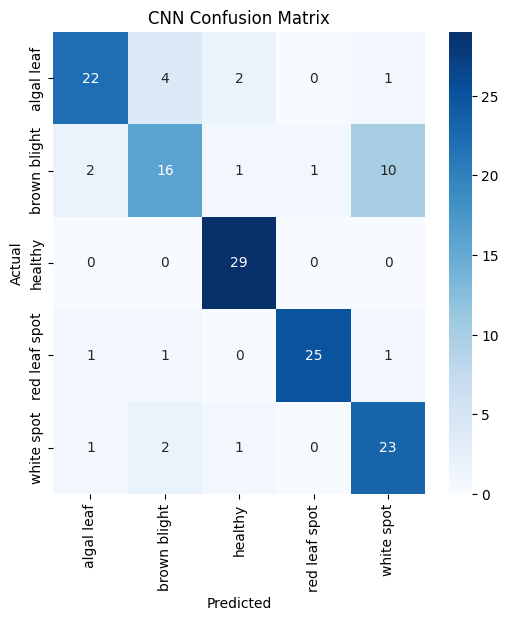

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_data.reset()

y_pred = np.argmax(cnn_model.predict(val_data), axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step


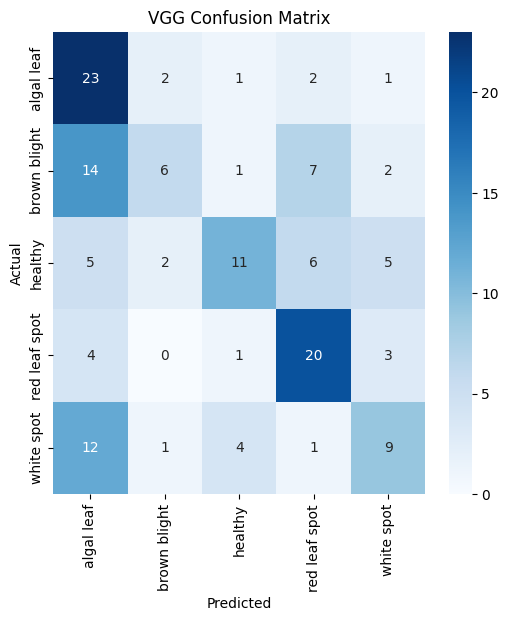

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_data.reset()

y_pred = np.argmax(vgg_model.predict(val_data), axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("VGG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 459ms/step


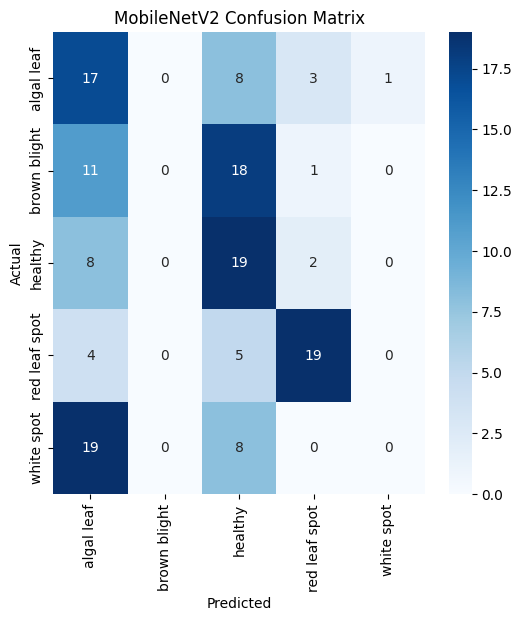

In [82]:
val_data.reset()

y_pred = np.argmax(mobile_model.predict(val_data), axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Evaluate Model

In [ ]:
# val_data.reset()

# predictions = model.predict(val_data)
# y_pred = np.argmax(predictions, axis=1)
# y_true = val_data.classes



8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 564ms/step


In [68]:
from collections import Counter

print(Counter(y_pred))

Counter({np.int64(4): 35, np.int64(2): 33, np.int64(0): 26, np.int64(3): 26, np.int64(1): 23})


In [69]:
from collections import Counter

print(Counter(train_data.classes))

Counter({np.int32(0): 120, np.int32(1): 120, np.int32(2): 117, np.int32(3): 115, np.int32(4): 109})


Test on Single Image

In [70]:
import cv2

In [71]:
# CNN
def predict_image(dataset):
    img = cv2.imread(dataset)          # Reads the image from disk
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = cnn_model.predict(img)
    class_index = np.argmax(prediction)

    class_names = list(train_data.class_indices.keys())

    return class_names[class_index]

In [72]:
# MobileNetV2
def predict_image_2(dataset):
    img = cv2.imread(dataset)          # Reads the image from disk
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = mobile_model.predict(img)
    class_index = np.argmax(prediction)

    class_names = list(train_data.class_indices.keys())

    return class_names[class_index]

In [73]:
# VGG16
def predict_image_vgg(dataset):
    img = cv2.imread(dataset)          # Reads the image from disk
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = vgg_model.predict(img)
    class_index = np.argmax(prediction)

    class_names = list(train_data.class_indices.keys())

    return class_names[class_index]

In [74]:
# ResNet50
def predict_image_res(dataset):
    img = cv2.imread(dataset)          # Reads the image from disk
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = resnet_model.predict(img)
    class_index = np.argmax(prediction)

    class_names = list(train_data.class_indices.keys())

    return class_names[class_index]

In [75]:
# Effi_B0
def predict_image_3(dataset):
    img = cv2.imread(dataset)          # Reads the image from disk
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = efficient_model.predict(img)
    class_index = np.argmax(prediction)

    class_names = list(train_data.class_indices.keys())

    return class_names[class_index]

In [ ]:
cnn_model.summary()

Test it using: CNN

In [218]:
print(predict_image(r"dataset\brown blight\brown_blight_00024.jpg"))
print(predict_image(r"dataset\healthy\healthy_00107.jpg"))
print(predict_image(r"dataset\algal leaf\tea_algal_leaf_spot_00001.jpg"))
print(predict_image(r"dataset\white spot\UNADJUSTEDNONRAW_thumb_7d.jpg"))
print(predict_image(r"dataset\red leaf spot\red_spider_00436.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
brown blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
algal leaf
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
white spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
algal leaf


In [219]:
# save model

cnn_model.save("tea_leaf_model.h5")


In [225]:
cnn_model.save("tea_leaf_model.keras")

Test using MobileNetV2

In [220]:
print(predict_image_2(r"dataset\brown blight\brown_blight_00024.jpg"))
print(predict_image_2(r"dataset\healthy\healthy_00107.jpg"))
print(predict_image_2(r"dataset\algal leaf\tea_algal_leaf_spot_00001.jpg"))
print(predict_image_2(r"dataset\white spot\UNADJUSTEDNONRAW_thumb_7d.jpg"))
print(predict_image_2(r"dataset\red leaf spot\red_spider_00436.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
white spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
healthy


In [76]:
mobile_model.save("mobilenet.keras")

Test using EffiecientB0

In [222]:
print(predict_image_3(r"dataset\brown blight\brown_blight_00024.jpg"))
print(predict_image_3(r"dataset\healthy\healthy_00107.jpg"))
print(predict_image_3(r"dataset\algal leaf\tea_algal_leaf_spot_00001.jpg"))
print(predict_image_3(r"dataset\white spot\UNADJUSTEDNONRAW_thumb_7d.jpg"))
print(predict_image_3(r"dataset\red leaf spot\red_spider_00436.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
healthy


Test using VGG16

In [223]:
print(predict_image_vgg(r"dataset\brown blight\brown_blight_00024.jpg"))
print(predict_image_vgg(r"dataset\healthy\healthy_00107.jpg"))
print(predict_image_vgg(r"dataset\algal leaf\tea_algal_leaf_spot_00001.jpg"))
print(predict_image_vgg(r"dataset\white spot\UNADJUSTEDNONRAW_thumb_7d.jpg"))
print(predict_image_vgg(r"dataset\red leaf spot\red_spider_00436.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
algal leaf
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
white spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
algal leaf
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
white spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
brown blight


In [77]:
vgg_model.save("vgg.keras")

test using ResNet50

In [224]:
print(predict_image_res(r"dataset\brown blight\brown_blight_00024.jpg"))
print(predict_image_res(r"dataset\healthy\healthy_00107.jpg"))
print(predict_image_res(r"dataset\algal leaf\tea_algal_leaf_spot_00001.jpg"))
print(predict_image_res(r"dataset\white spot\UNADJUSTEDNONRAW_thumb_7d.jpg"))
print(predict_image_res(r"dataset\red leaf spot\red_spider_00436.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
healthy


In [78]:
resnet_model.save("resnet.keras")

In [ ]:
# loads a previously saved model


# from tensorflow.keras.models import load_model
# model = load_model("tea_leaf_model.h5")


Model is best so far but weak

IMPROVE CNN

In [90]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,       #Splits dataset into training and validation
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.2,
    height_shift_range=0.2,

    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'

    )

In [92]:
train_data = datagen.flow_from_directory(
    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=20,
    class_mode='categorical',
    subset='training'
)


Found 581 images belonging to 5 classes.


In [93]:
val_data = datagen.flow_from_directory(
    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=20,
    class_mode='categorical',
    subset='validation',
    shuffle=False           # turn off shuffle
)

Found 143 images belonging to 5 classes.


In [94]:
# Build CNN
cnn_model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),   # “decision-making brain layer”
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax') # Produces probabilities for 5 classes - Sofmax ensures all outputs sum to 1
])


In [95]:
# compile

# “decision-making brain layer”
# configures how your neural network will learn. It does NOT train the model yet—it just sets the rules for training
from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    #optimizer=Adam(learning_rate=0.0005),               # how to learn - learning rate.
    optimizer='adam',  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [96]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 628ms/step - accuracy: 0.2134 - loss: 1.9041 - val_accuracy: 0.2657 - val_loss: 1.5946
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 647ms/step - accuracy: 0.2633 - loss: 1.5740 - val_accuracy: 0.2867 - val_loss: 1.5089
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 676ms/step - accuracy: 0.3356 - loss: 1.4596 - val_accuracy: 0.4056 - val_loss: 1.2256
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 649ms/step - accuracy: 0.3528 - loss: 1.3791 - val_accuracy: 0.4825 - val_loss: 1.2460
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 653ms/step - accuracy: 0.4269 - loss: 1.2806 - val_accuracy: 0.5385 - val_loss: 1.0417


In [97]:
cnn_loss, cnn_acc = cnn_model.evaluate(val_data)
print(cnn_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.2448 - loss: 1.5945
0.24475523829460144


In [125]:
np.save("history.npy", cnn_history.history)
np.save("mobile_history.npy", mobile_history.history)
np.save("vgg_history.npy", vgg_history.history)


FEEDBACK: from Melody

EDA: visualize other class images
- differenciate them better
- Grad-CAM (to explain preditiom of CNN)

before augmentation and after augment